In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from linearmodels import PanelOLS, RandomEffects, PooledOLS
from linearmodels.panel import compare
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# Set display options
pd.set_option('display.max_rows', 10)
pd.set_option('display.float_format', '{:.2f}'.format)

# Create the toy dataset
data = pd.DataFrame({
    'company': ['A', 'A', 'A', 'A', 'A',
                'B', 'B', 'B', 'B', 'B',
                'C', 'C', 'C', 'C', 'C',
                'D', 'D', 'D', 'D', 'D',
                'E', 'E', 'E', 'E', 'E'],
    'year': [2019, 2020, 2021, 2022, 2023] * 5,
    'profit_margin': [10.2, 10.5, 11.0, 10.8, 11.5,
                      15.1, 15.5, 16.0, 16.2, 17.0,
                      5.5, 5.8, 6.1, 6.0, 6.8,
                      20.1, 20.5, 21.0, 21.2, 22.0,
                      8.1, 8.5, 9.0, 8.8, 9.5],
    'rd_spending': [4.1, 4.3, 4.5, 4.4, 4.8,
                    2.1, 2.2, 2.5, 2.6, 3.0,
                    8.1, 8.3, 8.5, 8.4, 9.0,
                    1.1, 1.2, 1.5, 1.6, 2.0,
                    6.1, 6.3, 6.5, 6.4, 6.8]
})

# Display the first few rows
print("Dataset Preview:")
print(data.head(10))
print("\nDataset Info:")
print(f"Number of observations: {len(data)}")
print(f"Number of companies: {data['company'].nunique()}")
print(f"Years: {data['year'].min()} to {data['year'].max()}")

Dataset Preview:
  company  year  profit_margin  rd_spending
0       A  2019          10.20         4.10
1       A  2020          10.50         4.30
2       A  2021          11.00         4.50
3       A  2022          10.80         4.40
4       A  2023          11.50         4.80
5       B  2019          15.10         2.10
6       B  2020          15.50         2.20
7       B  2021          16.00         2.50
8       B  2022          16.20         2.60
9       B  2023          17.00         3.00

Dataset Info:
Number of observations: 25
Number of companies: 5
Years: 2019 to 2023


In [3]:
# IMPORTANT: Set the multi-index for panel data
# The index must be (entity, time) for linearmodels
data = data.set_index(['company', 'year'])
data = data.sort_index()

print("\nData with Panel Index:")
print(data.head(10))
print("\nIndex structure:")
print(data.index)


Data with Panel Index:
              profit_margin  rd_spending
company year                            
A       2019          10.20         4.10
        2020          10.50         4.30
        2021          11.00         4.50
        2022          10.80         4.40
        2023          11.50         4.80
B       2019          15.10         2.10
        2020          15.50         2.20
        2021          16.00         2.50
        2022          16.20         2.60
        2023          17.00         3.00

Index structure:
MultiIndex([('A', 2019),
            ('A', 2020),
            ('A', 2021),
            ('A', 2022),
            ('A', 2023),
            ('B', 2019),
            ('B', 2020),
            ('B', 2021),
            ('B', 2022),
            ('B', 2023),
            ('C', 2019),
            ('C', 2020),
            ('C', 2021),
            ('C', 2022),
            ('C', 2023),
            ('D', 2019),
            ('D', 2020),
            ('D', 2021),
            ('D'

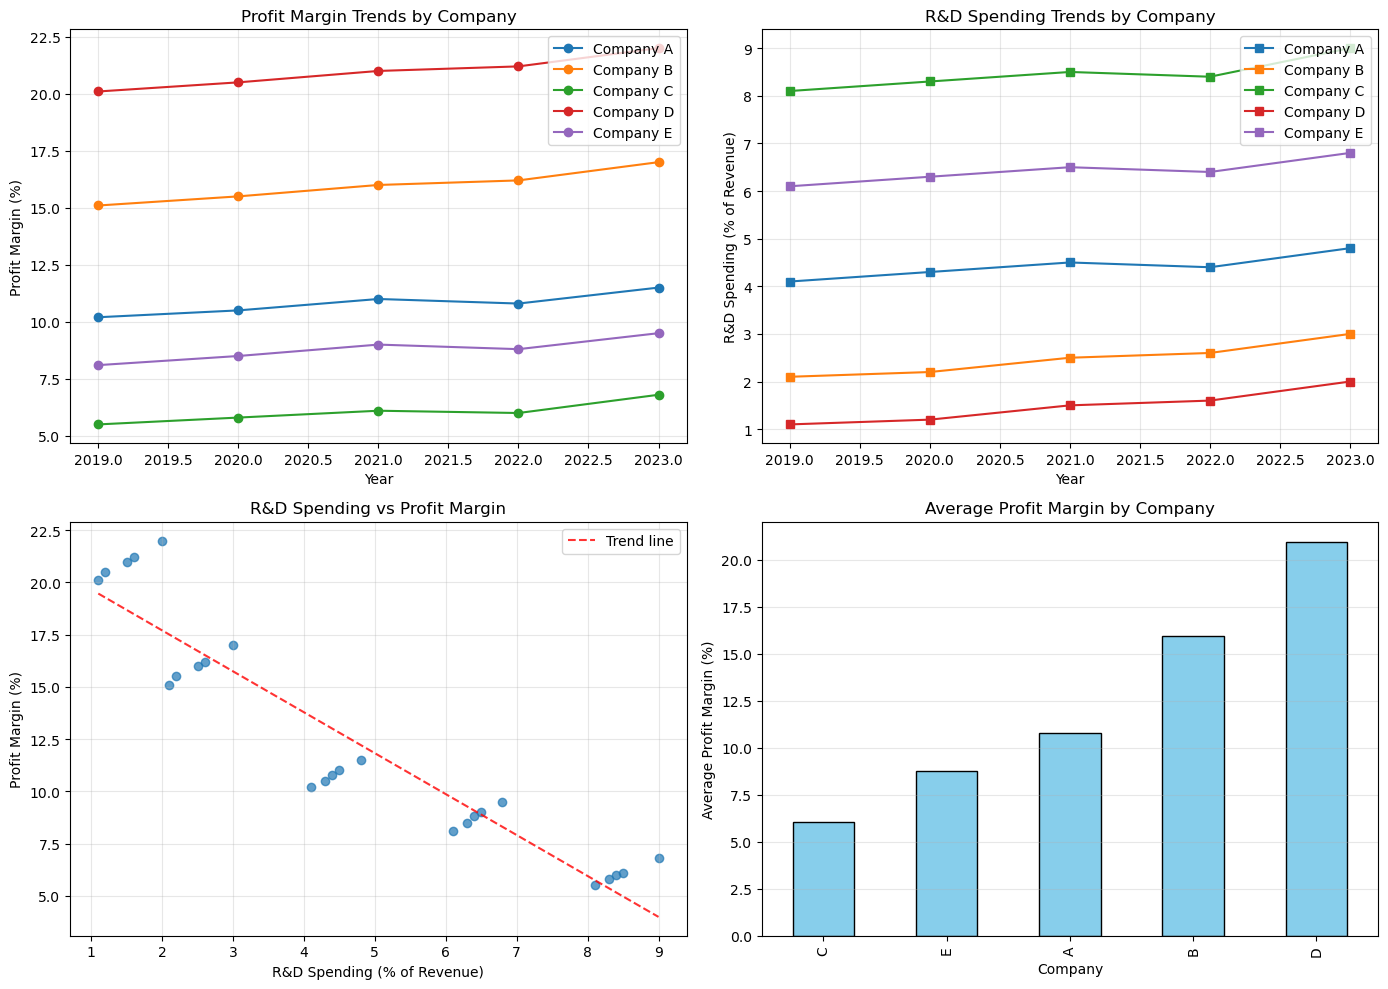


Summary Statistics:
       profit_margin  rd_spending
count          25.00        25.00
mean           12.51         4.65
std             5.47         2.62
min             5.50         1.10
25%             8.50         2.20
50%            10.80         4.40
75%            16.20         6.50
max            22.00         9.00

Variation Decomposition:
Between-company variation (standard deviation of company means):
profit_margin   5.96
rd_spending     2.85
dtype: float64

Within-company variation (average of within-company std devs):
profit_margin   0.59
rd_spending     0.31
dtype: float64


In [5]:
# Create visualization to understand the data
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Time trends by company
for company in data.index.get_level_values('company').unique():
    company_data = data.xs(company, level='company')
    axes[0, 0].plot(company_data.index, company_data['profit_margin'], 
                    marker='o', label=f'Company {company}')
axes[0, 0].set_title('Profit Margin Trends by Company')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Profit Margin (%)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. R&D spending trends
for company in data.index.get_level_values('company').unique():
    company_data = data.xs(company, level='company')
    axes[0, 1].plot(company_data.index, company_data['rd_spending'], 
                    marker='s', label=f'Company {company}')
axes[0, 1].set_title('R&D Spending Trends by Company')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('R&D Spending (% of Revenue)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Scatter plot: R&D vs Profit Margin
axes[1, 0].scatter(data['rd_spending'], data['profit_margin'], alpha=0.7)
axes[1, 0].set_xlabel('R&D Spending (% of Revenue)')
axes[1, 0].set_ylabel('Profit Margin (%)')
axes[1, 0].set_title('R&D Spending vs Profit Margin')
axes[1, 0].grid(True, alpha=0.3)

# Add a regression line
z = np.polyfit(data['rd_spending'], data['profit_margin'], 1)
p = np.poly1d(z)
axes[1, 0].plot(data['rd_spending'].sort_values(), 
                p(data['rd_spending'].sort_values()), 
                "r--", alpha=0.8, label='Trend line')
axes[1, 0].legend()

# 4. Boxplot by company
data.groupby('company')['profit_margin'].mean().sort_values().plot(
    kind='bar', ax=axes[1, 1], color='skyblue', edgecolor='black')
axes[1, 1].set_title('Average Profit Margin by Company')
axes[1, 1].set_xlabel('Company')
axes[1, 1].set_ylabel('Average Profit Margin (%)')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary statistics
print("\nSummary Statistics:")
print(data.describe())

# Between and within variation
print("\nVariation Decomposition:")
print("Between-company variation (standard deviation of company means):")
company_means = data.groupby('company').mean()
print(company_means.std())

print("\nWithin-company variation (average of within-company std devs):")
within_std = data.groupby('company').std().mean()
print(within_std)

In [12]:
# Prepare variables
# Note: linearmodels requires explicit addition of constant for some models
X = data[['rd_spending']]
y = data['profit_margin']

# Add constant for models that need it
X_with_const = sm.add_constant(X)

print("="*60)
print("PANEL DATA REGRESSION RESULTS")
print("="*60)

# 1. POOLED OLS (ignores panel structure)
print("\n1. POOLED OLS MODEL")
print("-"*40)
pooled_model = PooledOLS(y, X_with_const)
pooled_results = pooled_model.fit(cov_type='robust')
print(pooled_results)

# 2. FIXED EFFECTS MODEL (entity effects)
print("\n2. FIXED EFFECTS MODEL")
print("-"*40)
# entity_effects=True includes fixed effects for each company
fe_model = PanelOLS(y, X, entity_effects=True)
fe_results = fe_model.fit(cov_type='clustered', cluster_entity=True)
print(fe_results)

# 3. RANDOM EFFECTS MODEL
print("\n3. RANDOM EFFECTS MODEL")
print("-"*40)
re_model = RandomEffects(y, X_with_const)
re_results = re_model.fit(cov_type='robust')
print(re_results)

# 4. TWO-WAY FIXED EFFECTS (entity + time effects)
print("\n4. TWO-WAY FIXED EFFECTS MODEL")
print("-"*40)
twfe_model = PanelOLS(y, X, entity_effects=True, time_effects=True)
twfe_results = twfe_model.fit(cov_type='clustered', cluster_entity=True)
print(twfe_results)

PANEL DATA REGRESSION RESULTS

1. POOLED OLS MODEL
----------------------------------------
                          PooledOLS Estimation Summary                          
Dep. Variable:          profit_margin   R-squared:                        0.8794
Estimator:                  PooledOLS   R-squared (Between):              0.9198
No. Observations:                  25   R-squared (Within):              -3.1087
Date:                Fri, Feb 27 2026   R-squared (Overall):              0.8794
Time:                        19:30:52   Log-likelihood                   -50.991
Cov. Estimator:                Robust                                           
                                        F-statistic:                      167.68
Entities:                           5   P-value                           0.0000
Avg Obs:                       5.0000   Distribution:                    F(1,23)
Min Obs:                       5.0000                                           
Max Obs:         

In [13]:
fe_model = PanelOLS(y, X)
fe_results = fe_model.fit()
print(fe_results)

                          PanelOLS Estimation Summary                           
Dep. Variable:          profit_margin   R-squared:                        0.3931
Estimator:                   PanelOLS   R-squared (Between):              0.3922
No. Observations:                  25   R-squared (Within):               0.9554
Date:                Fri, Feb 27 2026   R-squared (Overall):              0.3931
Time:                        19:31:04   Log-likelihood                   -94.496
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      15.542
Entities:                           5   P-value                           0.0006
Avg Obs:                       5.0000   Distribution:                    F(1,24)
Min Obs:                       5.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             15.542
                            

In [15]:
fe_model = PanelOLS(y, X, time_effects=True)
fe_results = fe_model.fit(cov_type='clustered', cluster_entity=True)
print(fe_results)

                          PanelOLS Estimation Summary                           
Dep. Variable:          profit_margin   R-squared:                        0.9186
Estimator:                   PanelOLS   R-squared (Between):             -1.5911
No. Observations:                  25   R-squared (Within):              -3.2059
Date:                Fri, Feb 27 2026   R-squared (Overall):             -1.5936
Time:                        19:32:24   Log-likelihood                   -45.955
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      214.41
Entities:                           5   P-value                           0.0000
Avg Obs:                       5.0000   Distribution:                    F(1,19)
Min Obs:                       5.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             47.437
                            

In [16]:
fe_model = PanelOLS(y, X, entity_effects=True)
fe_results = fe_model.fit(cov_type='clustered', cluster_entity=True)
print(fe_results)

                          PanelOLS Estimation Summary                           
Dep. Variable:          profit_margin   R-squared:                        0.9751
Estimator:                   PanelOLS   R-squared (Between):              0.3813
No. Observations:                  25   R-squared (Within):               0.9751
Date:                Fri, Feb 27 2026   R-squared (Overall):              0.3823
Time:                        19:32:24   Log-likelihood                    26.246
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      744.40
Entities:                           5   P-value                           0.0000
Avg Obs:                       5.0000   Distribution:                    F(1,19)
Min Obs:                       5.0000                                           
Max Obs:                       5.0000   F-statistic (robust):             258.84
                            

In [7]:
print("\n" + "="*60)
print("HAUSMAN TEST: FE vs RE")
print("="*60)

# Run Hausman test
# We need to compare FE and RE coefficients
# Note: RE model must be run without constant for proper comparison
re_model_for_hausman = RandomEffects(y, X)  # No constant
re_results_h = re_model_for_hausman.fit()

# The hausman function compares FE and RE
# from linearmodels.panel import compare
hausman_results = fe_results.compare_f_test(re_results_h)  # FixedEffects results first
print("\nHausman Test Results:")
print(f"Test statistic: {hausman_results.stat:.4f}")
print(f"P-value: {hausman_results.pval:.4f}")
print(f"Degrees of freedom: {hausman_results.df:.0f}")

# Interpretation
if hausman_results.pval < 0.05:
    print("\n✅ INTERPRETATION: Reject H0 (p < 0.05)")
    print("   The RE assumption is violated. Use FIXED EFFECTS model.")
    print("   Unobserved company characteristics are correlated with R&D spending.")
    chosen_model = "Fixed Effects"
    chosen_results = fe_results
else:
    print("\n✅ INTERPRETATION: Fail to reject H0 (p >= 0.05)")
    print("   RE assumption holds. You could use RANDOM EFFECTS (more efficient).")
    print("   But many researchers still prefer FE for robustness.")
    chosen_model = "Random Effects"
    chosen_results = re_results

print(f"\n🎯 RECOMMENDED MODEL: {chosen_model}")


HAUSMAN TEST: FE vs RE


AttributeError: 'PanelEffectsResults' object has no attribute 'compare_f_test'